# Departure-Delay Regression

This notebook presents the chronological regression comparison produced by `src/run_regression.py`. The modelling script must be run first to regenerate the committed summary tables and figures.

## Question

How accurately can route, stop, and scheduled service information predict departure delay on later observations?

## Method

The training period is January–April, validation is May, and the held-out test period is June. A global median and historical grouped median provide baselines. Ridge regression supplies a regularized linear comparison, while Random Forest represents nonlinear relationships. MAE is the primary selection metric.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
comparison = pd.read_csv(TABLE_DIR / 'regression_model_comparison.csv')
fallbacks = pd.read_csv(TABLE_DIR / 'regression_grouped_baseline_fallbacks.csv')
importance = pd.read_csv(TABLE_DIR / 'regression_feature_importance.csv')
assert set(comparison['phase']) == {'validation', 'test'}
print(f'Loaded {len(comparison)} evaluation results.')

Loaded 7 evaluation results.


## Result: validation comparison

The May validation results determine which machine-learning candidate proceeds to the held-out test.

,model,mae_seconds,rmse_seconds,r2,selected_for_test
0,Historical grouped median,107.7796,161.7782,0.0570,False
1,Random Forest,110.9784,158.5167,0.0946,True
2,Ridge regression,113.8783,156.9870,0.1120,False
3,Global median baseline,115.9627,172.5143,-0.0723,False


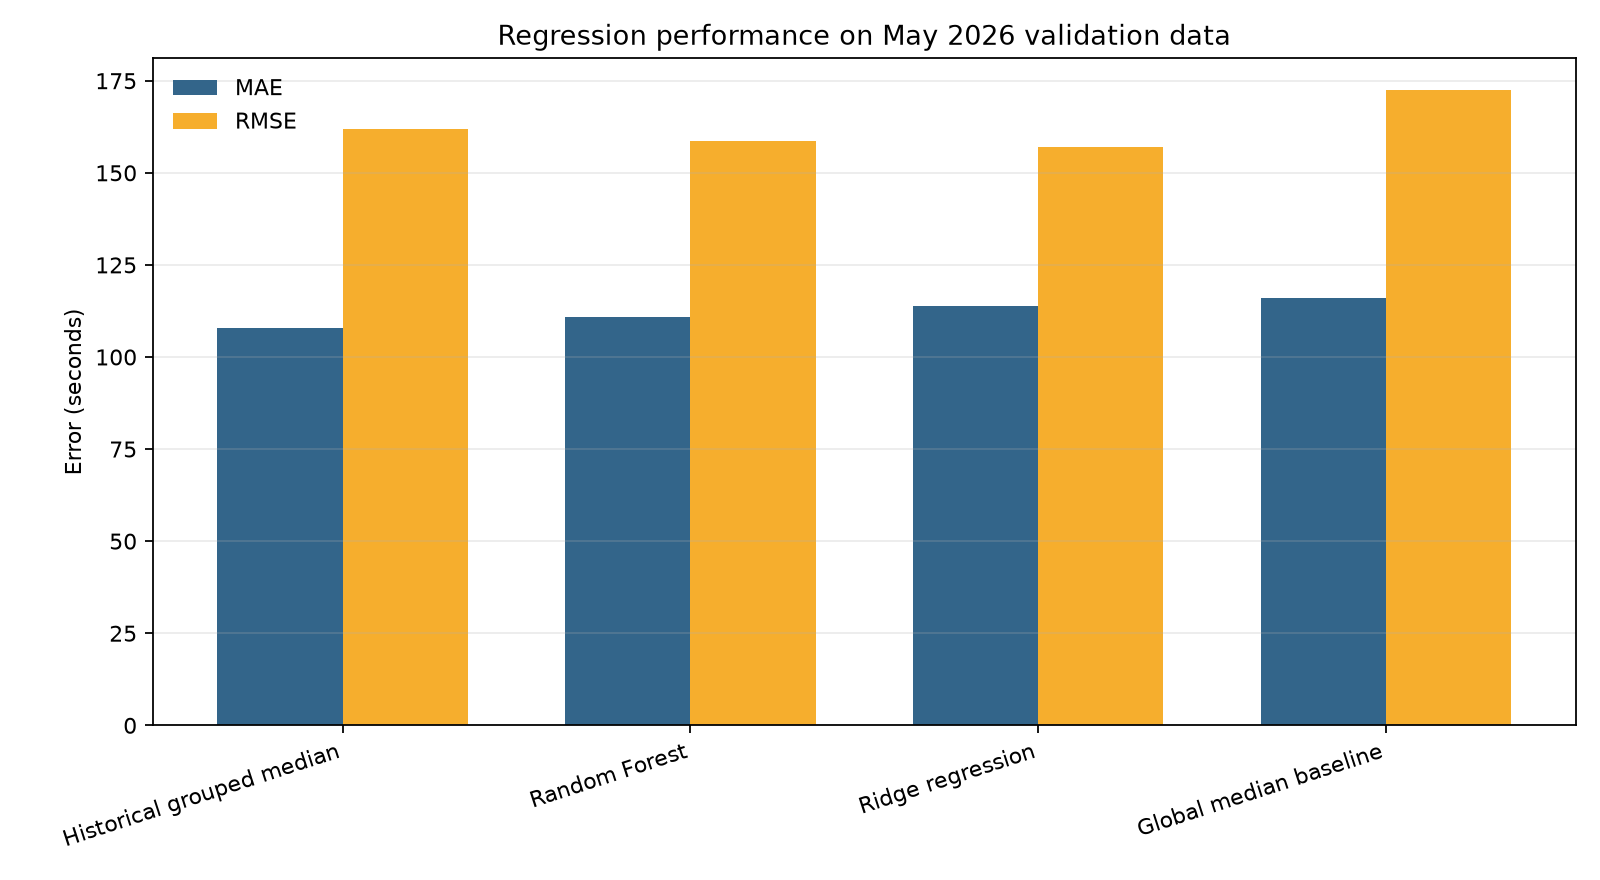

In [2]:
validation = comparison.loc[comparison['phase'].eq('validation'), ['model', 'mae_seconds', 'rmse_seconds', 'r2', 'selected_for_test']]
display(validation.sort_values('mae_seconds').reset_index(drop=True))
display(Image(filename=str(FIGURE_DIR / 'regression_validation_comparison.png')))

## Interpretation

The historical grouped median has the lowest validation MAE at 107.78 seconds. Random Forest has the lower MAE of the two machine-learning candidates at 110.98 seconds, compared with 113.88 seconds for Ridge, so it is selected before June is examined. Ridge has the lowest RMSE and highest R², showing that the preferred method depends on the chosen error criterion.

## Result: held-out June test

Random Forest is refitted on January–May, and the three predefined approaches are evaluated on June.

,model,mae_seconds,rmse_seconds,r2
0,Historical grouped median,101.3334,148.9466,0.0906
1,Random Forest,106.3309,149.0029,0.0899
2,Global median baseline,109.3188,159.6007,-0.0441


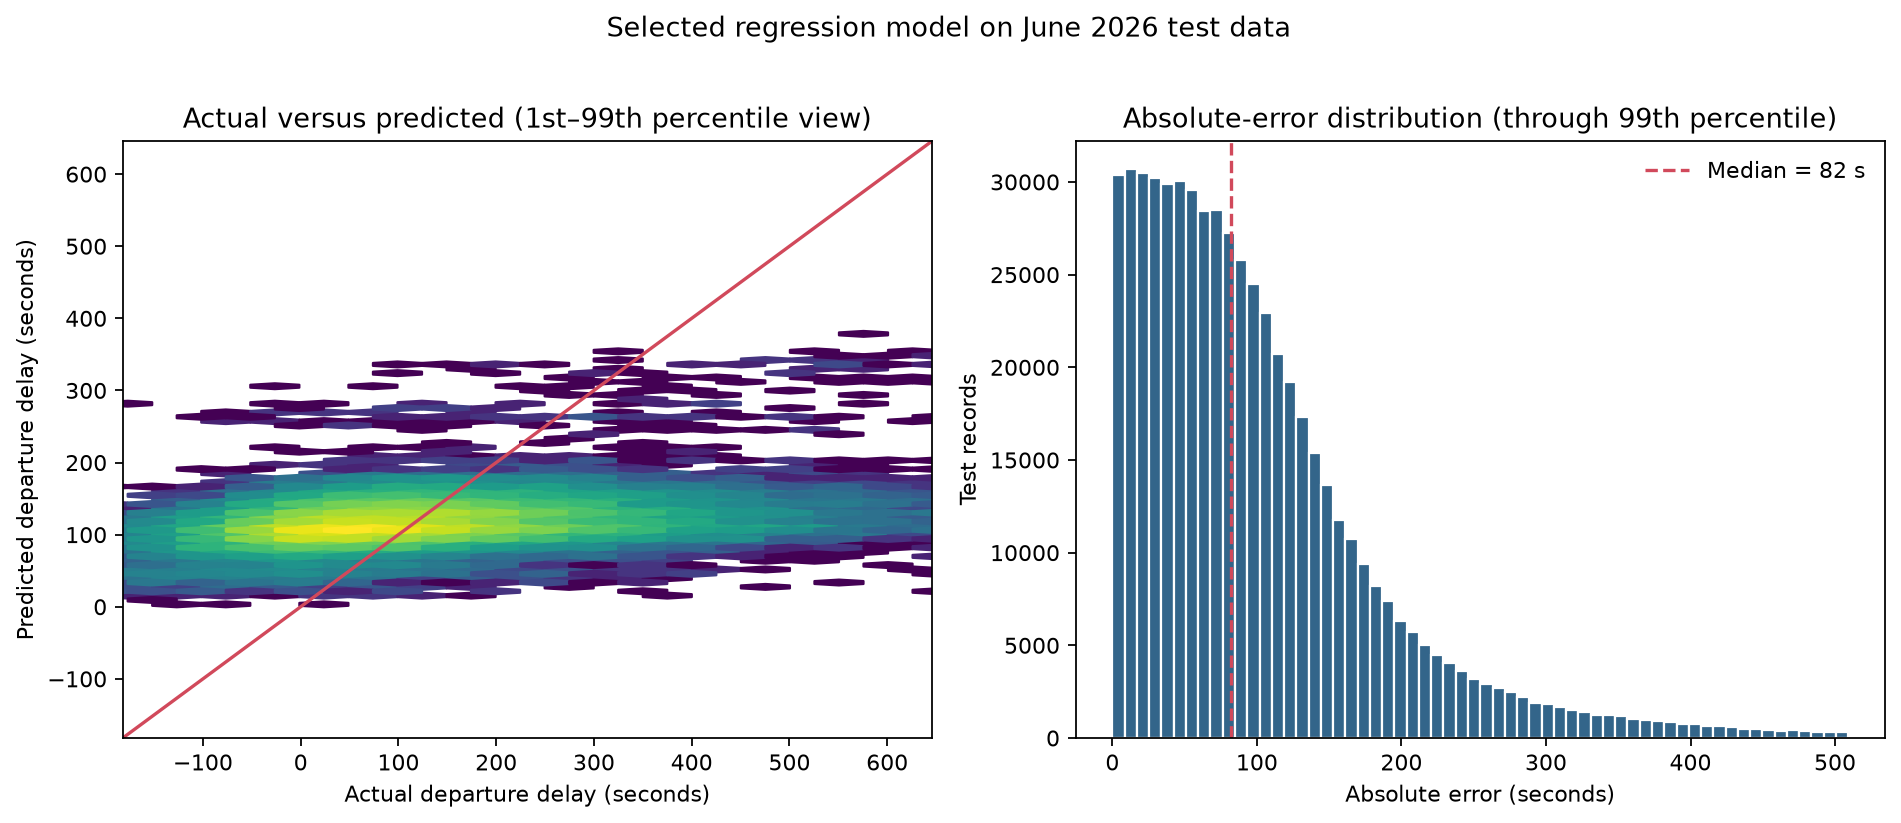

In [3]:
test = comparison.loc[comparison['phase'].eq('test'), ['model', 'mae_seconds', 'rmse_seconds', 'r2']]
display(test.sort_values('mae_seconds').reset_index(drop=True))
display(Image(filename=str(FIGURE_DIR / 'regression_test_performance.png')))

## Interpretation

The historical grouped median remains best on June with an MAE of 101.33 seconds. Random Forest reaches 106.33 seconds and improves only modestly on the 109.32-second global baseline. Its R² of 0.090 indicates that most event-level variation remains unexplained. Predictions concentrate around typical delays and do not reproduce extreme outcomes well.

## Question: how often does the grouped baseline fall back?

In [4]:
display(fallbacks.loc[fallbacks['phase'].eq('test')].reset_index(drop=True))

,phase,fallback_level,records,percent
0,test,route + stop + weekday + hour,411702,71.7711
1,test,route + stop + hour,158413,27.6158
2,test,route + stop,3457,0.6027
3,test,route,60,0.0105
4,test,global median,0,0.0000


## Interpretation

More than 71% of June records use the most specific route-stop-weekday-hour grouping, and over 27% use route-stop-hour. No record requires the global fallback. This broad historical coverage helps explain the baseline's strong performance.

## Question: which fields did the Random Forest use most?

In [5]:
display(importance)

,feature,importance,method
0,route_name,0.352172,impurity-based importance
1,stop_id,0.205187,impurity-based importance
2,service_day_of_week,0.145966,impurity-based importance
3,service_month_number,0.080876,impurity-based importance
4,stop_sequence,0.077936,impurity-based importance
5,direction_code,0.073465,impurity-based importance
6,scheduled_minute_of_service_day,0.064398,impurity-based importance


## Interpretation and limitations

Route and stop have the largest aggregated impurity importances, followed by service day of week. These values describe how the fitted trees split the data; they do not demonstrate causal effects. Schedule-only predictors omit traffic, weather, passenger demand, incidents, and preceding vehicle conditions, which likely contributes to the modest predictive performance.